# Exploratory Data Analysis (EDA) - Vietnamese Recipe Dataset

In [2]:
import ast
import re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

pd.options.display.max_columns = None
pd.options.display.float_format = "{:.2f}".format
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['font.family'] = 'DejaVu Sans'

DATA_PATH = Path("all_recipes_final.csv")
recipes = pd.read_csv(DATA_PATH)

In [3]:
recipes.head(3)

,title,type_of_food,link,description,ingredients,ingredients_normalized,step,note,num_of_ingredients,cook_time,num_of_people,calories,source
0,Cách muối dưa hành truyền thống,Món Tết,https://vnexpress.net/doi-song-cooking-cach-mu...,Dưa hành muối là món ăn truyền thống ngày Tết ...,"['1 kg hành củ tươi', 'Tro bếp hoặc nước vo gọ...","{'tro bếp hoặc nước vo gọa', 'đường', 'cà rốt ...",['Bước 1: Chọn hành củ: Nên chọn hành củ ta bá...,[],5,45 phút,8-10 người,459 kcal,vnexpress
1,Su hào xào mực - món cổ Tết Bát Tràng,Món Tết,https://vnexpress.net/doi-song-cooking-su-hao-...,Đĩa xào khô ráo với su hào giòn ngọt quyện với...,"['2 củ su hào non', '1 con mực khô', '1/2 củ c...","{'muối', 'mỡ lợn hoặc dầu ăn', 'đường', 'gia v...",['Bước 1: Chọn và sơ chế mực: Người dân làng g...,['Su hào xào mực cùng với canh măng mực là hai...,6,50 phút,4 - 5 người,1.162 kcal,vnexpress
2,Canh măng ngày Tết cổ truyền Hà Nội,Món Tết,https://vnexpress.net/doi-song-cooking-canh-ma...,"Măng ngấu vị, giòn ngon, móng giò hầm vừa độ s...","['800 gr măng khô', '2 móng giò lợn', 'Nước dù...","{'muối', 'móng giò lợn', 'nước vo gạo ngâm măn...","['Bước 1: Chọn măng khô: Theo lối cũ, người nộ...",['Nếu tận dụng nước luộc gà nấu canh măng thì ...,6,100 phút,8 - 10 người,4.930 kcal,vnexpress


In [4]:
pd.DataFrame({
    "Rows": len(recipes),
    "Columns": recipes.shape[1],
    "Unique Titles": recipes['title'].nunique(),
    "Duplicate Rate (%)": round((1 - recipes['title'].nunique() / len(recipes)) * 100, 2),
    "Memory (MB)": round(recipes.memory_usage(deep=True).sum() / 1024**2, 2)
}, index=["Value"]).T

,Value
Rows,10263.00
Columns,13.00
Unique Titles,10262.00
Duplicate Rate (%),0.01
Memory (MB),61.52


In [5]:
recipes.dtypes.to_frame(name="dtype")

,dtype
title,object
type_of_food,object
link,object
description,object
ingredients,object
ingredients_normalized,object
step,object
note,object
num_of_ingredients,int64
cook_time,object


In [6]:
def parse_range(text):
    if pd.isna(text):
        return None
    numbers = [int(num) for num in re.findall(r"\d+", str(text))]
    return float(np.mean(numbers)) if numbers else None

def safe_literal_eval(value):
    if pd.isna(value) or not isinstance(value, str) or value.strip() == "":
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, (list, set)) else []
    except:
        return []

def parse_set_string(value):
    if pd.isna(value) or not isinstance(value, str):
        return set()
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, set) else set()
    except:
        return set()

recipes['cook_time_minutes'] = recipes['cook_time'].apply(parse_range)
recipes['num_people_est'] = recipes['num_of_people'].apply(parse_range)
recipes['calories_kcal'] = recipes['calories'].apply(parse_range)
recipes['title_word_count'] = recipes['title'].fillna('').str.split().str.len()
recipes['description_word_count'] = recipes['description'].fillna('').str.split().str.len()

ingredient_lists = recipes['ingredients'].apply(safe_literal_eval)
ingredient_normalized_sets = recipes['ingredients_normalized'].apply(parse_set_string)
step_lists = recipes['step'].apply(safe_literal_eval)

recipes['ingredients_count'] = ingredient_lists.apply(len)
recipes['ingredients_normalized_count'] = ingredient_normalized_sets.apply(len)
recipes['steps_count'] = step_lists.apply(len)

In [7]:
numeric_cols = ['ingredients_count', 'ingredients_normalized_count', 'steps_count', 
                'cook_time_minutes', 'num_people_est', 'calories_kcal']
recipes[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T

,count,mean,std,min,25%,50%,75%,95%,max
ingredients_count,10263.00,8.60,3.89,1.00,6.00,8.00,11.00,16.00,32.00
ingredients_normalized_count,10263.00,8.89,4.23,1.00,6.00,8.00,11.00,16.00,57.00
steps_count,10263.00,6.24,2.88,1.00,4.00,6.00,8.00,12.00,46.00
cook_time_minutes,9968.00,44.81,70.88,1.00,20.00,30.00,45.00,120.00,1439.00
num_people_est,9969.00,10.78,55.45,1.00,2.00,4.00,4.00,10.00,970.00
calories_kcal,437.00,300.98,243.03,1.00,114.50,250.00,432.00,865.40,998.00


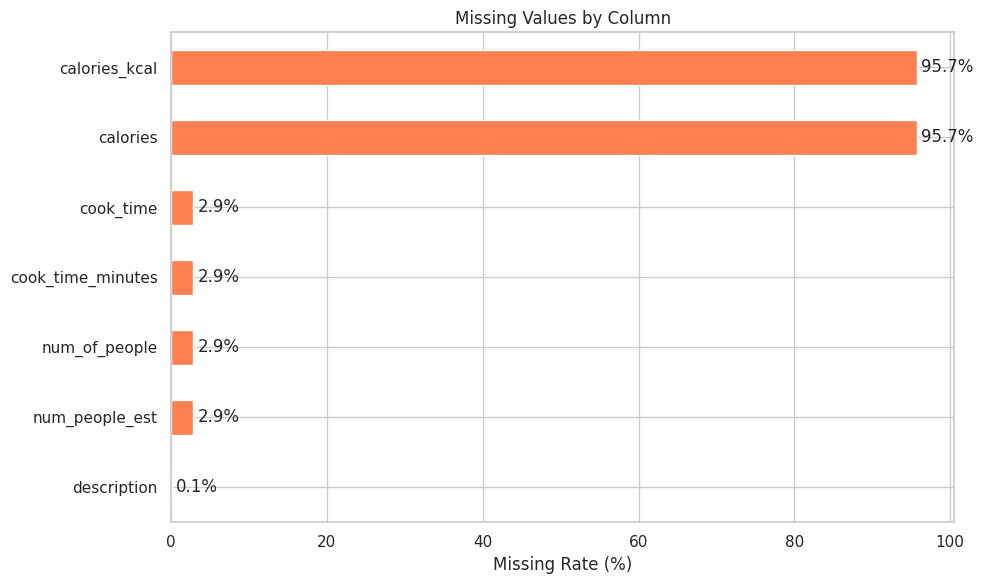

In [8]:
missing_pct = (recipes.isna().sum() / len(recipes) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Values by Column')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5856\874590465.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=type_counts.index, x=type_counts.values, ax=axes[1], palette='viridis')


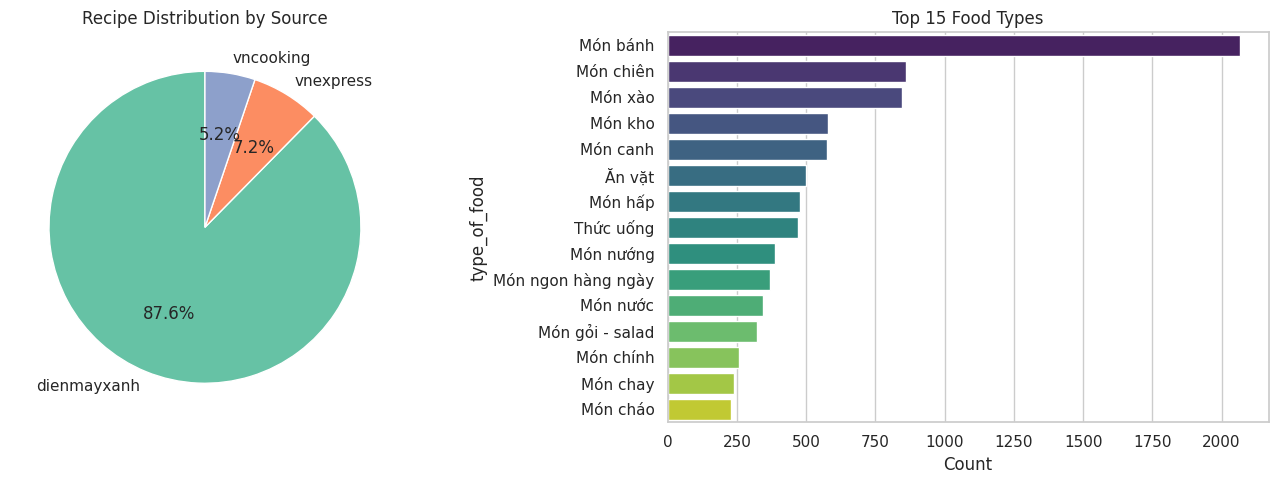

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = recipes['source'].value_counts()
axes[0].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Recipe Distribution by Source')

type_counts = recipes['type_of_food'].fillna('Unknown').value_counts().head(15)
sns.barplot(y=type_counts.index, x=type_counts.values, ax=axes[1], palette='viridis')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Food Types')

plt.tight_layout()
plt.show()

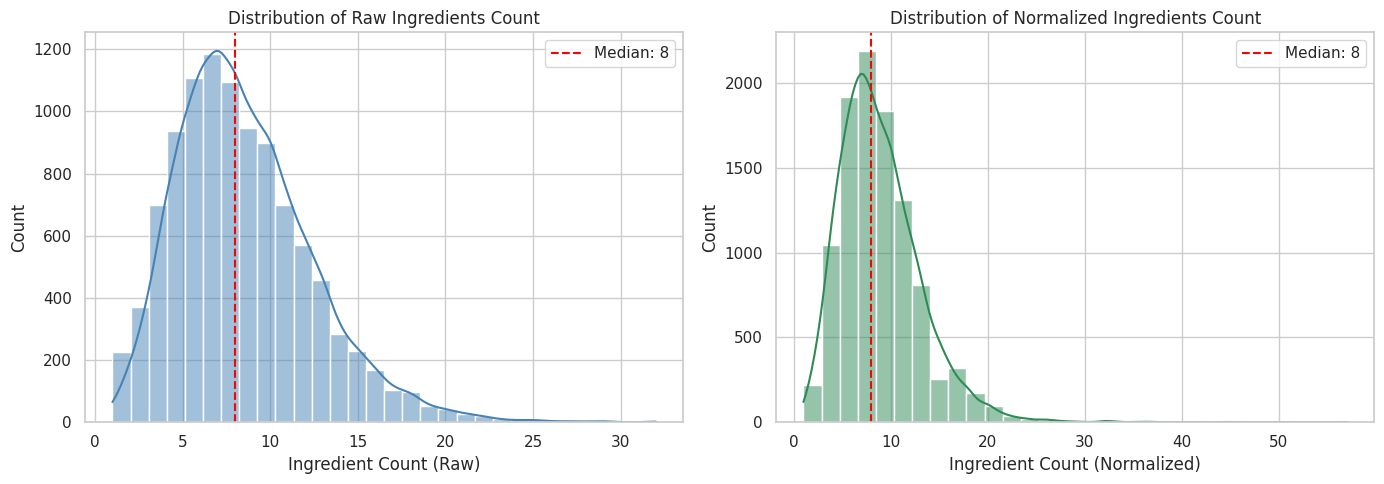

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(recipes['ingredients_count'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Ingredient Count (Raw)')
axes[0].set_title('Distribution of Raw Ingredients Count')
axes[0].axvline(recipes['ingredients_count'].median(), color='red', linestyle='--', label=f"Median: {recipes['ingredients_count'].median():.0f}")
axes[0].legend()

sns.histplot(recipes['ingredients_normalized_count'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_xlabel('Ingredient Count (Normalized)')
axes[1].set_title('Distribution of Normalized Ingredients Count')
axes[1].axvline(recipes['ingredients_normalized_count'].median(), color='red', linestyle='--', label=f"Median: {recipes['ingredients_normalized_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5856\163421406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ingredients, y='ingredient', x='count', ax=axes[0], palette='coolwarm')


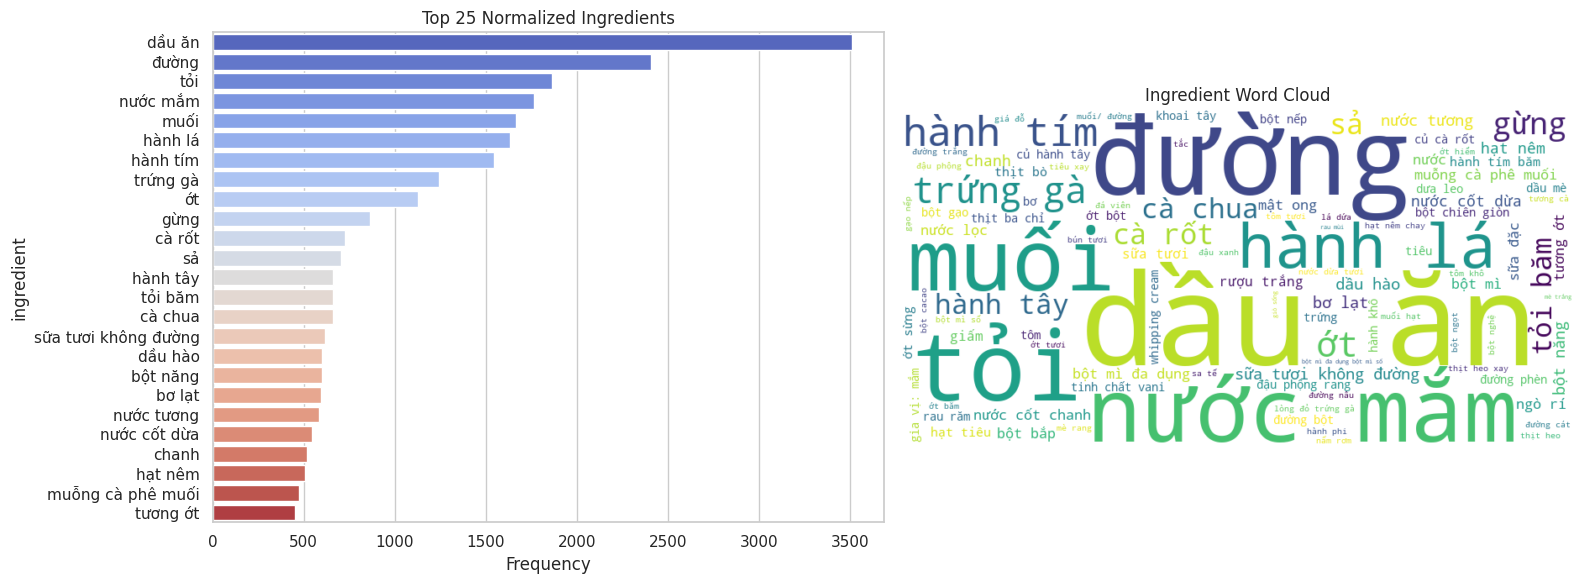

In [11]:
ingredient_counter = Counter()
for ing_set in ingredient_normalized_sets:
    ingredient_counter.update(ing_set)

top_ingredients = pd.DataFrame(ingredient_counter.most_common(25), columns=['ingredient', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_ingredients, y='ingredient', x='count', ax=axes[0], palette='coolwarm')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 25 Normalized Ingredients')

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100)
wordcloud.generate_from_frequencies(ingredient_counter)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ingredient Word Cloud')

plt.tight_layout()
plt.show()

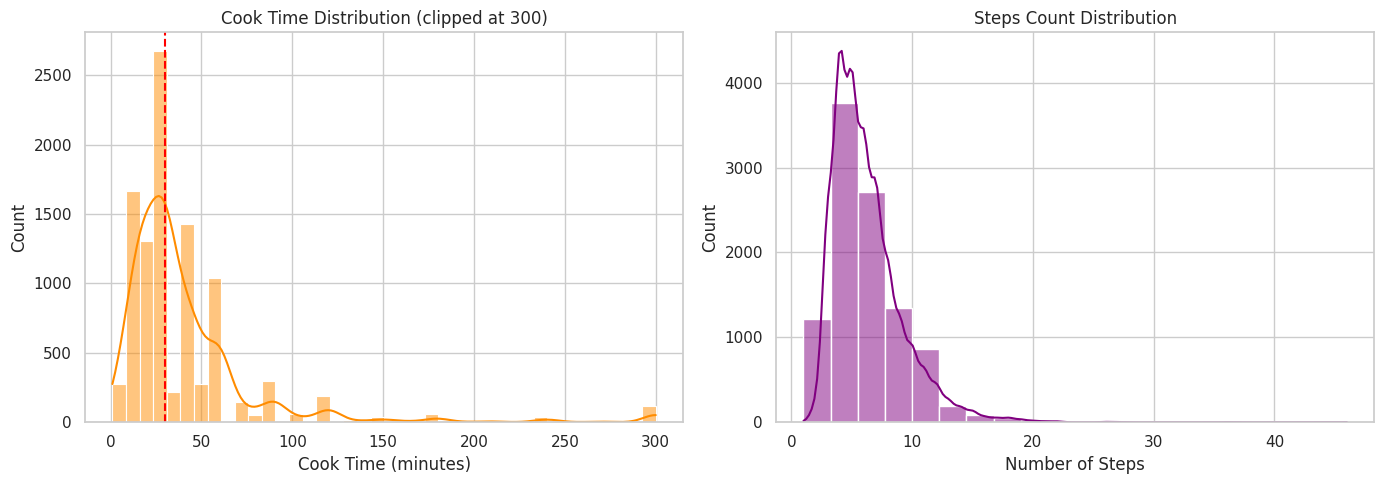

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cook_time = recipes['cook_time_minutes'].dropna().clip(upper=300)
sns.histplot(cook_time, bins=40, kde=True, ax=axes[0], color='darkorange')
axes[0].set_xlabel('Cook Time (minutes)')
axes[0].set_title('Cook Time Distribution (clipped at 300)')
axes[0].axvline(cook_time.median(), color='red', linestyle='--')

sns.histplot(recipes['steps_count'], bins=20, kde=True, ax=axes[1], color='purple')
axes[1].set_xlabel('Number of Steps')
axes[1].set_title('Steps Count Distribution')

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5856\924596940.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pairs, y='pair', x='count', palette='Spectral')


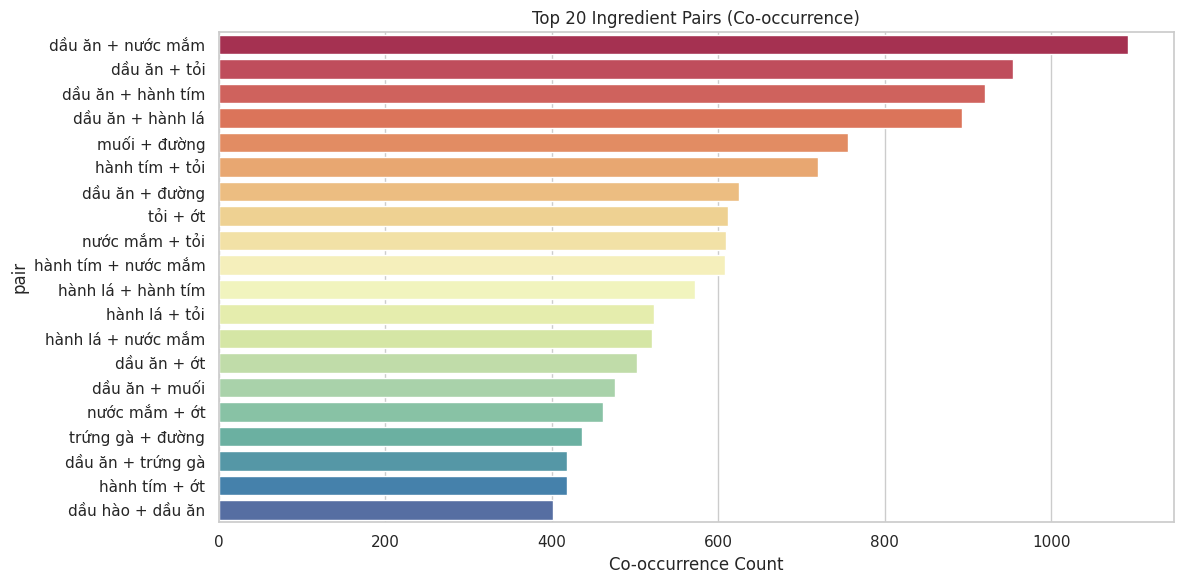

In [18]:
from itertools import combinations

pair_counter = Counter()
for ing_set in ingredient_normalized_sets:
    ing_list = list(ing_set)
    if len(ing_list) >= 2:
        for pair in combinations(sorted(ing_list), 2):
            pair_counter[pair] += 1

top_pairs = pd.DataFrame(pair_counter.most_common(20), columns=['pair', 'count'])
top_pairs['pair'] = top_pairs['pair'].apply(lambda x: f"{x[0]} + {x[1]}")

plt.figure(figsize=(12, 6))
sns.barplot(data=top_pairs, y='pair', x='count', palette='Spectral')
plt.xlabel('Co-occurrence Count')
plt.title('Top 20 Ingredient Pairs (Co-occurrence)')
plt.tight_layout()
plt.show()

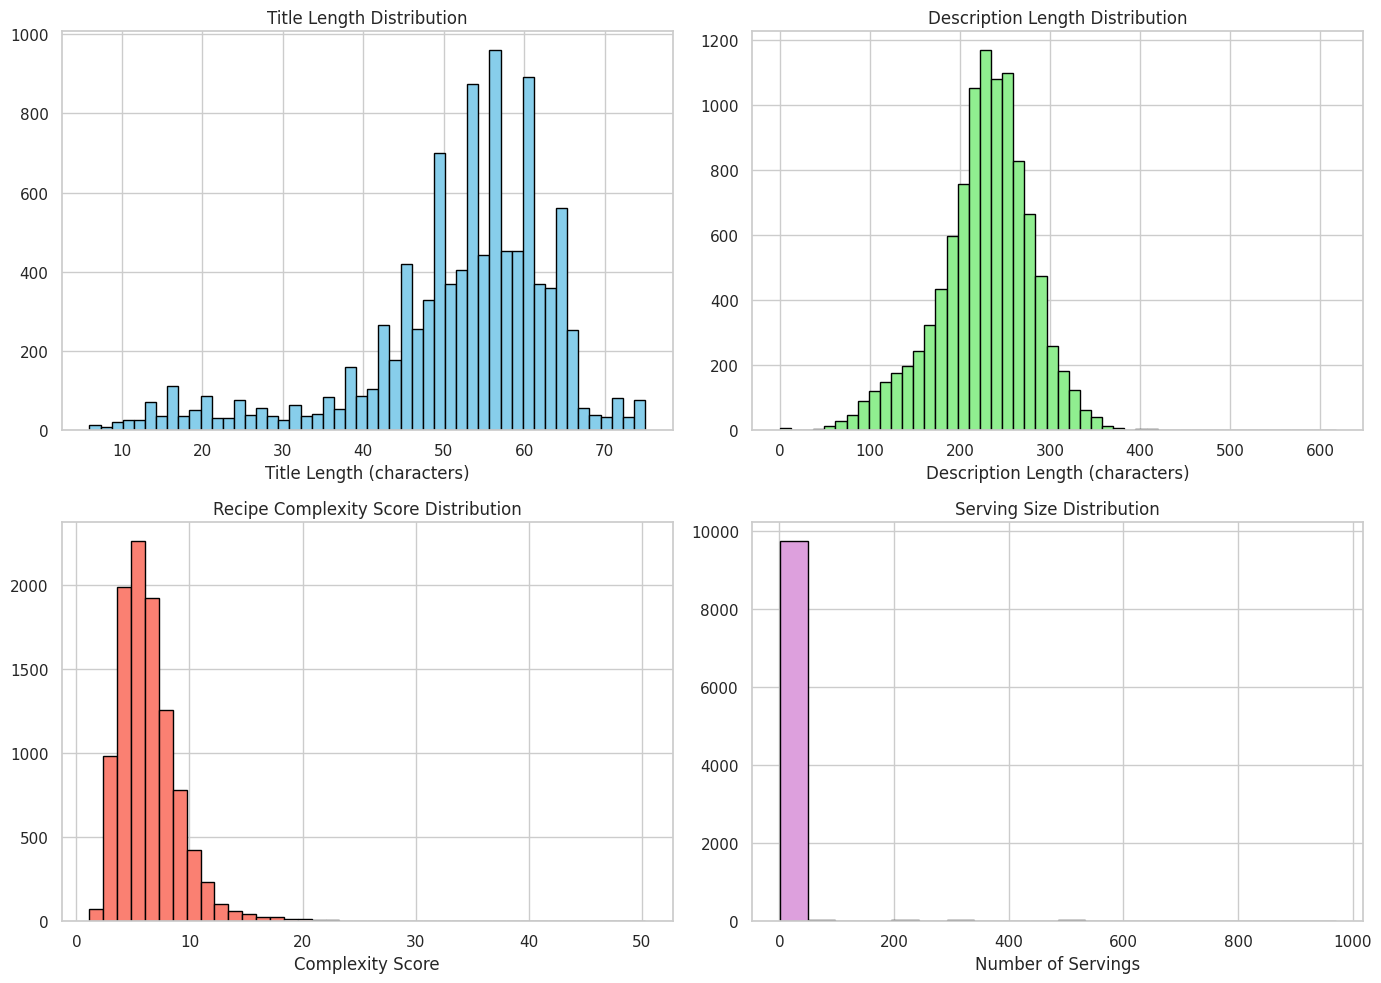

In [19]:
title_lengths = recipes['title'].str.len()
desc_lengths = recipes['description'].str.len().fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(title_lengths, bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Title Length (characters)')
axes[0, 0].set_title('Title Length Distribution')

axes[0, 1].hist(desc_lengths, bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Description Length (characters)')
axes[0, 1].set_title('Description Length Distribution')

recipes['complexity_score'] = (
    recipes['ingredients_normalized_count'] * 0.3 +
    recipes['steps_count'] * 0.4 +
    recipes['cook_time_minutes'].fillna(0) / 10 * 0.3
)
axes[1, 0].hist(recipes['complexity_score'], bins=40, color='salmon', edgecolor='black')
axes[1, 0].set_xlabel('Complexity Score')
axes[1, 0].set_title('Recipe Complexity Score Distribution')

serving_counts = recipes['num_people_est'].dropna()
axes[1, 1].hist(serving_counts, bins=20, color='plum', edgecolor='black')
axes[1, 1].set_xlabel('Number of Servings')
axes[1, 1].set_title('Serving Size Distribution')

plt.tight_layout()
plt.show()

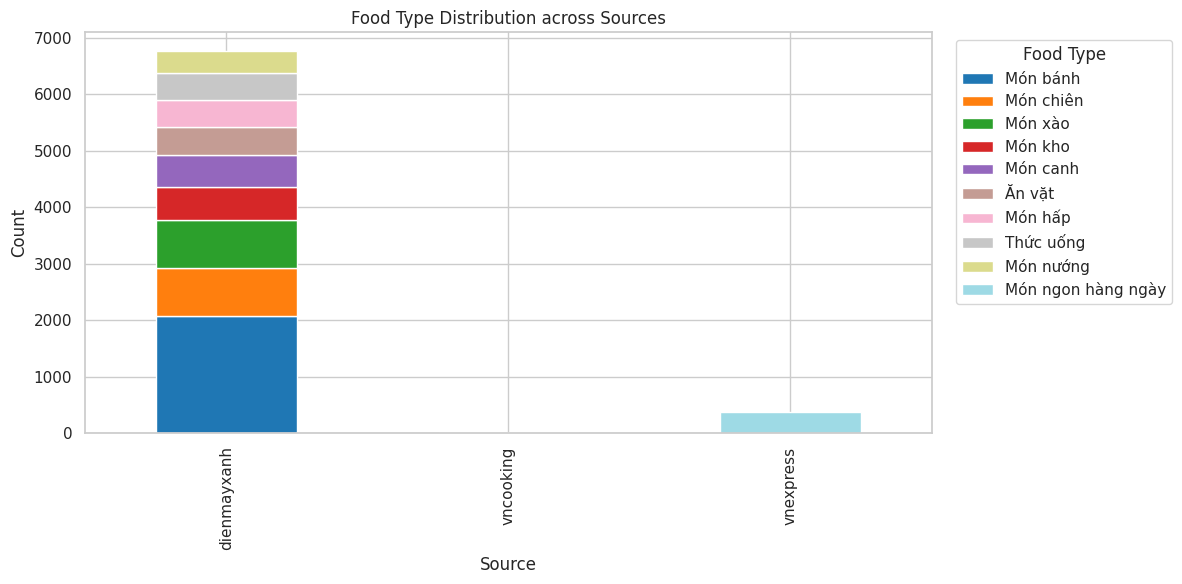

In [20]:
source_type_cross = pd.crosstab(recipes['source'], recipes['type_of_food'].fillna('Unknown'))
top_types_cross = source_type_cross.sum().nlargest(10).index
source_type_filtered = source_type_cross[top_types_cross]

source_type_filtered.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.xlabel('Source')
plt.ylabel('Count')
plt.title('Food Type Distribution across Sources')
plt.legend(title='Food Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
unique_ingredients = set()
for ing_set in ingredient_normalized_sets:
    unique_ingredients.update(ing_set)

summary_stats = pd.DataFrame({
    'Metric': ['Total Recipes', 'Unique Ingredients', 'Unique Food Types', 
               'Avg Ingredients/Recipe', 'Avg Steps/Recipe', 'Avg Cook Time (min)',
               'Recipes with Calories', 'Median Calories'],
    'Value': [
        len(recipes),
        len(unique_ingredients),
        recipes['type_of_food'].nunique(),
        recipes['ingredients_normalized_count'].mean(),
        recipes['steps_count'].mean(),
        recipes['cook_time_minutes'].mean(),
        recipes['calories_kcal'].notna().sum(),
        recipes['calories_kcal'].median()
    ]
})
summary_stats['Value'] = summary_stats['Value'].apply(lambda x: f"{x:.2f}" if isinstance(x, float) else x)
summary_stats

,Metric,Value
0,Total Recipes,10263.00
1,Unique Ingredients,18090.00
2,Unique Food Types,42.00
3,Avg Ingredients/Recipe,8.89
4,Avg Steps/Recipe,6.24
5,Avg Cook Time (min),44.81
6,Recipes with Calories,437.00
7,Median Calories,250.00
